This project focuses on cleaning and analyzing a messy e-commerce dataset to extract meaningful business insights. It involves data preprocessing, transformation, and visualization using Python libraries such as pandas , matplotlib, and seaborn.

In [474]:
#Import all necessary libraries 
import numpy as np
import pandas as pd
import os
from word2number import w2n
import seaborn as sns
import matplotlib.pyplot as plt

In [475]:
#Get path
cwd  = os.getcwd()
print(cwd)

C:\Users\lefte\datasets


Get Data  & Quick Inspection

In [476]:
#Change the current working directory to the specified path
os.chdir('C:/Users/lefte/datasets')

In [477]:
#Read the CSV file into a DataFrame
data = pd.read_csv('ecommerce_sales_data.csv')


In [478]:
# Display the first 10 rows of the DataFrame
data.head(10)
#We notice name inconsistencies in the column names, so we will rename them for better readability and consistency.

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51
5,105,Customer_105,ORD-22442,2024-11-20,Tennis Racket,Sports,3,122.06,Cash on Delivery,Cancelled,366.18
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
7,107,Customer_107,ORD-89122,2025-01-03,Biography,Books,5,587.68,PayPal,Returned,2938.40
8,108,Customer_108,ORD-64400,2025-10-23,Science,Books,1,600.29,Cash on Delivery,Processing,600.29
9,109,Customer_109,ORD-18512,2025-05-03,Tennis Racket,Sports,5,168.34,Credit Card,Shipped,841.70


In [479]:
# Display the summary information about the DataFrame
data.info()
# We notice that Order Date is str instead of Datetime, and Quantity and Price are also str instead of numeric. Product - Category - Payment Method and Status -> Categorical.
#  We will convert them to the appropriate data types.
# 103 rows and 10 columns.

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    str    
 2   Order_ID        103 non-null    str    
 3   Order_Date      103 non-null    str    
 4    Product        103 non-null    str    
 5   Category        95 non-null     str    
 6   Quantity        98 non-null     str    
 7   Price           98 non-null     str    
 8   Payment_Method  103 non-null    str    
 9   Status          103 non-null    str    
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), str(9)
memory usage: 9.0 KB


In [480]:
#Check for spaces in the ColumnNames
print(list(data.columns))

['ID', ' Customer_Name', 'Order_ID', 'Order_Date', ' Product', 'Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']


In [481]:
# There were spaces in the column names, so we will strip them to avoid any issues with accessing the columns.
data.columns = data.columns.str.strip()

In [482]:
# First rename columns
data = data.rename(columns = {"Customer_Name": "Customer Name", "Order_ID": "Order ID", "Order_Date": "Order Date",  "Payment_Method": "Payment Method"})

In [483]:
data

,ID,Customer Name,Order ID,Order Date,Product,Category,Quantity,Price,Payment Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38,Cash on Delivery,Shipped,114.000
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.050
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,PayPal,Processing,1169.600
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash on Delivery,Processing,552.510
...,...,...,...,...,...,...,...,...,...,...,...
98,198,Customer_198,ORD-14608,2025-07-27,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,2025-01-22,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2025-02-24,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,2025-10-30,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300


Check for duplicates and missing values !

In [484]:
#fιnd duplicate rows in the DataFrame and remove them (103 -> 102 rows)
duplicates = data[data.duplicated()]
print(duplicates)
data.drop_duplicates(inplace = True)

      ID Customer Name   Order ID  Order Date     Product    Category  \
102  146  Customer_146  ORD-32755  2025-07-09  Basketball  electronic   

    Quantity   Price Payment Method      Status    Total  
102        2  705.42  Bank Transfer  Processing  1410.84  


In [485]:
#Check missing values in the DataFrame
missing = data.isna().sum()[data.isna().sum() > 0].sort_values(ascending=False)
print(missing)

Total       14
Category     8
Quantity     5
Price        5
dtype: int64


*** NUMERIC VARIABLES TRANSFORMATION ***

Clean & Transform "Price" Column

In [486]:
#Let's check what kind of trashes we have in "Price" column.
mask = pd.to_numeric(data['Price'], errors='coerce').isna()
print(data.loc[mask, 'Price'])
#Conv four hundred to 400, remove dollar sign and the rest = NAs

1              abd
10    four hundred
16             NaN
20            300$
24             NaN
30             NaN
56             NaN
83             NaN
96             abd
Name: Price, dtype: str


In [487]:
#Convert words to numbers in the "Price" column
def convert_words(x):
    try:
        return w2n.word_to_num(x)
    except:
        return x

data['Price'] = data['Price'].apply(convert_words)

In [488]:
#Convert the "Price" column to numeric, coercing errors to NaN
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

In [489]:
#Check if there is any negative price and exclude the "-" 
data[data['Price'] < 0]
data["Price"] = data["Price"].replace({-100: 100})

#Previously we had noticed a dollar sign (300$) for customer_120, but by converting the string to float, the value was converted to "missing" value. That is why manually we insert that value back to that row.

data.loc[data['ID'] == 120, 'Price'] = 300

In [490]:
#Check the summary statistics of "Price" Column - Check for outliers 
data["Price"].describe()

count       95.000000
mean       608.587684
std       1008.159863
min         38.000000
25%        270.900000
50%        531.060000
75%        733.815000
max      10000.000000
Name: Price, dtype: float64

In [491]:
#Outlier detected
data[data["Price"] >= 10000]

#Outlier dropped
data = data[data["ID"] != 117 ]


Clean & Transform "Quantity" Column

In [492]:
data["Quantity"].str.strip()

0      3
1      2
2      1
3      5
4      1
      ..
97     1
98     2
99     5
100    1
101    5
Name: Quantity, Length: 101, dtype: str

In [493]:
#Column has negative signs and extra characters such as "a". We will remove them and convert the column to numeric.
data['Quantity'] = data['Quantity'].str.replace(r'\D', '', regex=True)
data['Quantity'] = data['Quantity'].astype('Int64')


Clean & Tranform "Total" Column

In [494]:
#There are negative signs in this column. So, we clean them up.

data['Total'] = data['Total'].abs()


In [495]:
#We can Derive some "Total" values from the multiplication of Price * Quantity. That's what we do here. Correspondingly, we can get other values based on calculations.
data["Total"] = data["Total"].fillna(data["Price"] * data["Quantity"])

#Price
data["Price"] = data["Price"].fillna(data["Total"] / data["Quantity"])

#Quantity
data["Quantity"] = data["Quantity"].fillna(data["Total"] / data["Price"])


In [496]:
#Drop the rows where "Price" and "Total" Values are not presence.
data = data.dropna(subset=["Total", "Price"])

Transform "ORDER ID" column - We leave the Customer_ID untouched. 

In [497]:
#Exclude "ORD-" from "ORDER ID" col 
data["Order ID"] = data['Order ID'].str.replace('ORD-', '', regex=False)


 *** CATEGORICAL VARIABLES TRANSFORMATION ***

Clean & Tranform  "Category - Product - Payment Method - Status" Columns

In [498]:
#Inspect "Status" Column -> Looks clean !
data["Status"].value_counts()

Status
Returned      25
Shipped       21
Processing    20
Cancelled     14
Delivered     10
Name: count, dtype: int64

In [499]:
#Convert "Status" Column, str -> cat
data[["Status"]] = data[["Status"]].astype('category')

In [500]:
#Inspect  "Payment Method" Column. We can save up some space and Convert [Cash on delivery] to [Cash] and [Credit Card] to [Card].
data["Payment Method"].value_counts()

#First, convert "Status" Column from str to category
data[["Payment Method"]] = data[["Payment Method"]].astype('category')

In [501]:
#Then convert the categories
data["Payment Method"] = data["Payment Method"].cat.rename_categories(
    lambda x: "Cash" if x == "Cash on Delivery"
    else "Card" if x == "Credit Card"
    else x
)
data["Payment Method"].value_counts()

Payment Method
Cash             29
Card             22
PayPal           20
Bank Transfer    19
Name: count, dtype: int64

In [502]:
#Check "Product" Column
data["Product"].value_counts().sort_index(ascending=True)
#We notice that the last category "shoes" has s low case and there is already a "Shoes" category with S Upper Case. 

Product
Basketball       5
Biography        5
Blender          6
Comics           6
Fiction          5
Football         2
Headphones       3
Jacket           3
Jeans            2
Lamp             7
Laptop           4
Microwave        4
Science          6
Shoes            7
Smartphone       4
Smartwatch       3
T-shirt          3
Tennis Racket    5
Vacuum           4
Yoga Mat         5
shoes            1
Name: count, dtype: int64

In [503]:
#So, we combine (add them up) these two. Convert str -> cat
data["Product"] = data["Product"].str.lower().str.capitalize()
data[["Product"]] = data[["Product"]].astype('category')
data["Product"].value_counts().sort_index(ascending=True)



Product
Basketball       5
Biography        5
Blender          6
Comics           6
Fiction          5
Football         2
Headphones       3
Jacket           3
Jeans            2
Lamp             7
Laptop           4
Microwave        4
Science          6
Shoes            8
Smartphone       4
Smartwatch       3
T-shirt          3
Tennis racket    5
Vacuum           4
Yoga mat         5
Name: count, dtype: int64

In [504]:
# Check values of "Category" Column
data["Category"].value_counts()
# Class "electronics" has several different format -> standardization

Category
Books          21
Home           17
Sports         13
Clothing       13
Electronics    10
ELECTRONICS     3
electronics     3
electronic      2
sports          1
Name: count, dtype: int64

In [505]:
# We standardize the class "electronics" and convert the str to category.
data["Category"] = data["Category"].str.lower().str.capitalize()
data[["Category"]] = data[["Category"]].astype('category')
data["Category"] = data["Category"].replace({"Electronic": "Electronics"})

In [506]:
data["Category"].value_counts()

Category
Books          21
Electronics    18
Home           17
Sports         14
Clothing       13
Electronic      0
Name: count, dtype: int64

In [507]:
#Remove class "Electronic" with 0 cases.
data["Category"] = data["Category"].cat.remove_unused_categories()

In [508]:
#Check number of NAs values
data["Category"].isna().sum()

np.int64(7)

In [509]:
#Replace NAs values with "Unknown" Category for better interpretation
data["Category"] = data["Category"].cat.add_categories("Unknown").fillna("Unknown")

DATE TIME TRANSFORMATION & CLEANING

In [510]:
#Convert Jan 5 2023 to yyyy-mm-dd
data['Order Date'] = data['Order Date'].str.replace(
    r'([A-Za-z]+)\s+(\d{1,2})\s+(\d{4})',
    lambda x: pd.to_datetime(x.group(0)).strftime('%Y-%m-%d'),
    regex=True)

#Convert 05/01/2023 to 2023-01-05
mask = data['Order Date'].str.contains(r'/')

data.loc[mask, 'Order Date'] = data.loc[mask, 'Order Date'].str.replace(
    r'(\d{1,2})/(\d{1,2})/(\d{4})',
    r'\3-\2-\1',
    regex=True)

In [511]:
#Convert "Order Date" Column from str -> Date type
data['Order Date'] = pd.to_datetime(
    data['Order Date'],
    dayfirst=True,
    errors='coerce' 
).dt.date   

C:\Users\lefte\AppData\Local\Temp\ipykernel_13292\3444316106.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data['Order Date'] = pd.to_datetime(


DEEPER CHECK FOR DUPLICATES 

In [512]:
#Check for duplicates
data = data.sort_values(by='ID')
duplicates = data[data.duplicated(subset='ID', keep=False)]
print(duplicates)

#The correct rows are the ones in which the multiplication of Price and Quantity gives the correct number. On that case, row 42 and 100 are incorrect and will be removed from our dataset.

      ID Customer Name Order ID  Order Date     Product     Category  \
42   142  Customer_142    69018  2025-10-30       Shoes     Clothing   
101  142  Customer_142    69018  2025-10-30       Shoes     Clothing   
75   175  Customer_175    56651  2025-02-24  Headphones  Electronics   
100  175  Customer_175    56651  2025-02-24  Headphones  Electronics   

     Quantity   Price Payment Method      Status    Total  
42          5  645.26           Card     Shipped  2258.41  
101         5  645.26           Card     Shipped   3226.3  
75          1  111.36           Card  Processing   111.36  
100         1  111.36           Card  Processing   77.952  


In [513]:
#Remove the above mentioned rows
data = data[
    ~(
        ((data['ID'] == 142) & (data['Total'] == 2258.410)) |
        ((data['ID'] == 175) & (data['Total'] == 77.952))
    )
]

#If we had more than 2 cases, we would have made it dynamic with a loop but because loops can be really computational and time expensive, we decided to exclude the values "manually"\

In [514]:
# One last check of "Missing Values" before we proceed to the visualization
data.isna().sum()

# We have only 1 NA value on Date variable and we keep it.

ID                0
Customer Name     0
Order ID          0
Order Date        1
Product           0
Category          0
Quantity          0
Price             0
Payment Method    0
Status            0
Total             0
dtype: int64

In [515]:
#As we are not going to do any Advanced and Deep analysis, data or model development we decide not to drop the Missing values.
#In case we were proceeed to Data modeling or Machine Learning Model we would decide wisely what to do with the NAs values.

*** VISUALIZATION PART WITH SEABORN AND MATPLOTLIB ***

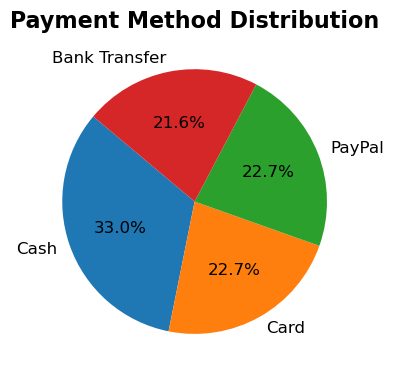

In [516]:
#Check Payment Method Distribution - Pie Chart
payment_counts = data['Payment Method'].value_counts()

plt.figure(figsize=(4,4))

wedges, texts, autotexts = plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('Payment Method Distribution', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

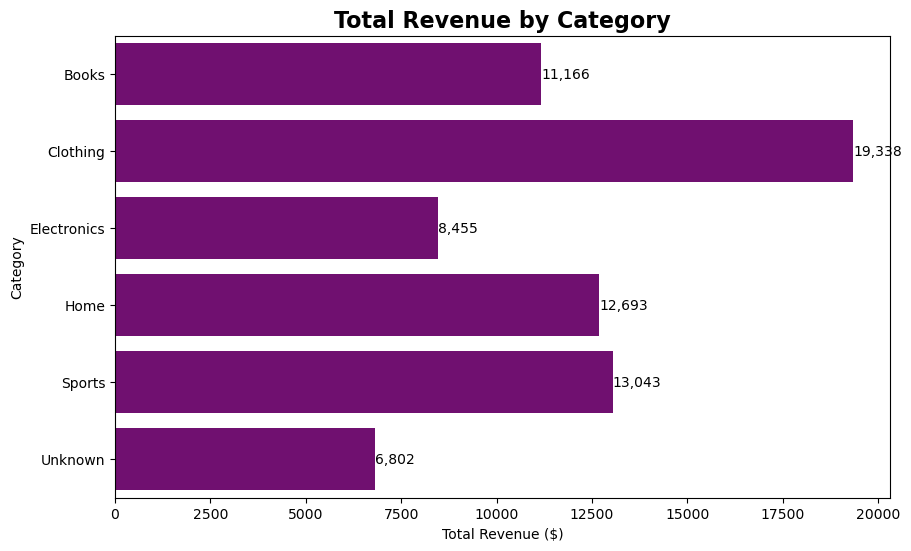

In [518]:
#Show "Total Revenue by Category" excluding  canceled and returned orders
filtered_data = data[~data["Status"].isin(["Cancelled", "Returned"])]
cat_sales = filtered_data.groupby('Category', as_index=False)['Total'].sum()
cat_sales = cat_sales.sort_values(by='Total', ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=cat_sales, x='Total', y='Category', color="purple")

for i, row in cat_sales.iterrows():
    ax.text(row['Total'], i, f"{row['Total']:,.0f}",
            va='center', ha='left')

plt.title('Total Revenue by Category', fontsize=16, weight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')

plt.show()

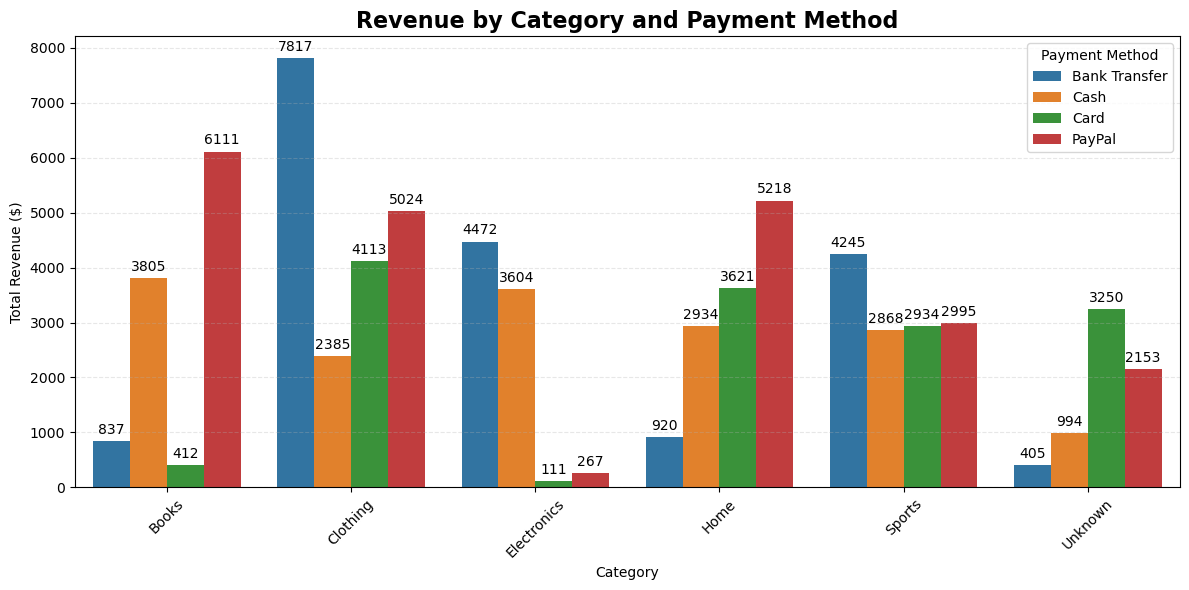

In [519]:
#Revenue by Category and Payment Method

filtered_data = data[~data["Status"].isin(["Cancelled", "Returned"])] ## filter retuned and canceled orders

pivot = filtered_data.groupby(['Category', 'Payment Method'])['Total'].sum().reset_index()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=pivot,
    x='Category',
    y='Total',
    hue='Payment Method'
)

plt.title('Revenue by Category and Payment Method', fontsize=16, weight='bold')
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.legend(title='Payment Method')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

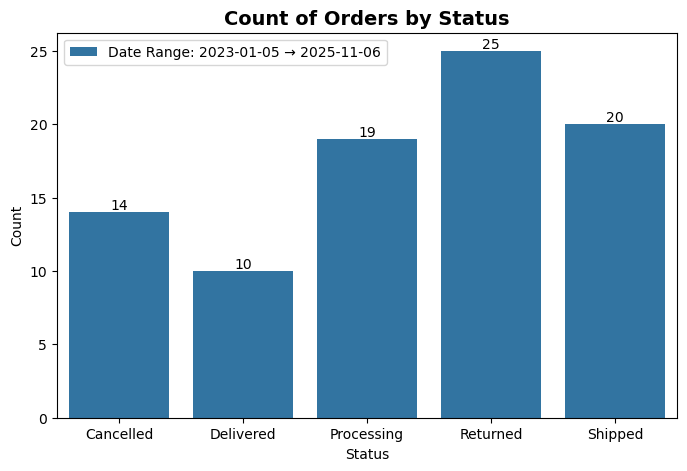

In [520]:
#Count of Orders by Status from 2023-01-05 -> 2025-11-06

#Create a copy of original dataset
data_plot = data.copy()
#change date format to datetime
data_plot["Order Date"] = pd.to_datetime(data["Order Date"])
#Find first and last day of order
start_date = data_plot["Order Date"].min().strftime("%Y-%m-%d")
end_date = data_plot["Order Date"].max().strftime("%Y-%m-%d")

#plot
plt.figure(figsize=(8,5))
ax = sns.countplot(data=data, x="Status")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.legend([f"Date Range: {start_date} → {end_date}"], loc="upper left")

plt.title("Count of Orders by Status", fontsize=14, weight='bold')
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

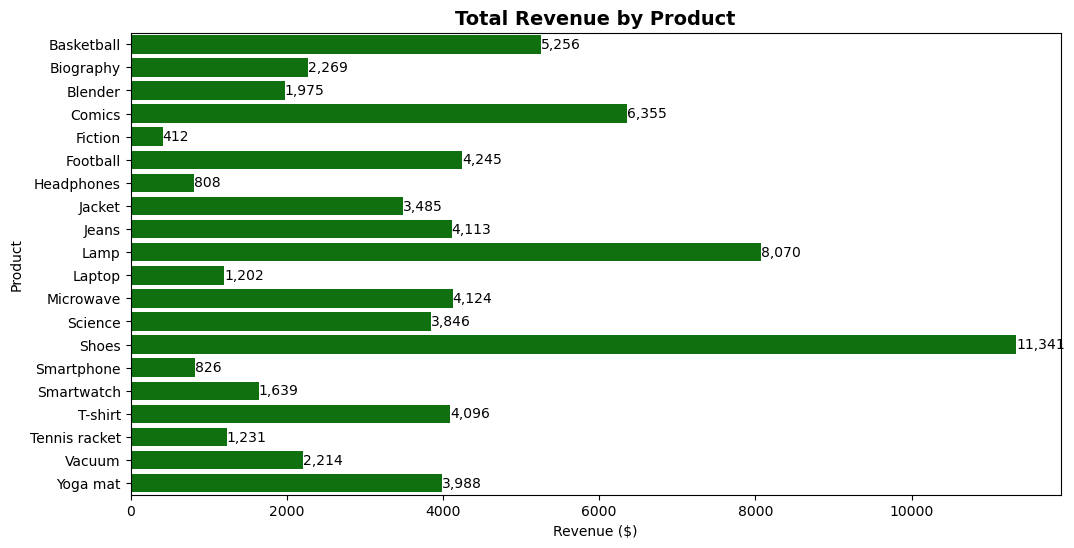

In [521]:
#Total Revenue by Product excluding the cancelled and returned Orders.
clean = data[~data["Status"].isin(["Cancelled", "Returned"])]
product_sales = clean.groupby("Product", as_index=False)["Total"].sum()
product_sales = product_sales.sort_values(by="Total", ascending=False)

plt.figure(figsize=(12,6))
ax = sns.barplot(data=product_sales, x="Total", y="Product", color= "green")

for i, row in product_sales.iterrows():
    ax.text(row["Total"], i, f"{row['Total']:,.0f}",
            va='center', ha='left')

plt.title("Total Revenue by Product", fontsize=14, weight='bold')
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

plt.show()

SUMMARY

We cleaned and standardized the dataset by handling missing values, fixing data types, removing duplicates, and correcting inconsistencies across numerical and categorical features. Then, we performed exploratory data analysis by creating visualizations to understand revenue patterns, order behavior, and customer trends—such as revenue by category/product and order status distribution.